In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from error_correction_experiments import run_error_correction_parameter_sweep

In [2]:
df = run_error_correction_parameter_sweep(
    n=8000,
    trials_per_setting=20,
    block_sizes=[8, 16, 32, 64],
    pass_counts=[1, 3, 5, 7, 10],
    eve_intercept_prob=0.05,
    channel_noise_prob=0.02
)

df

,block_size,passes,eve_intercept_prob,channel_noise_prob,trials_per_setting,qubits_per_trial,success_rate,average_qber,average_raw_key_length,average_raw_mismatches,average_final_mismatches,average_corrections_applied,average_parity_checks
0,8,1,0.05,0.02,20,8000,0.00,0.030377,4009.80,121.80,22.8,99.00,798.60
1,8,3,0.05,0.02,20,8000,1.00,0.031826,3997.30,127.25,0.0,127.25,1882.00
2,8,5,0.05,0.02,20,8000,1.00,0.031393,4010.60,125.90,0.0,125.90,2886.15
3,8,7,0.05,0.02,20,8000,1.00,0.031415,4000.55,125.65,0.0,125.65,3880.75
4,8,10,0.05,0.02,20,8000,1.00,0.032331,3987.55,128.90,0.0,128.90,5374.65
5,16,1,0.05,0.02,20,8000,0.00,0.031754,4000.00,127.00,46.8,80.20,570.85
6,16,3,0.05,0.02,20,8000,1.00,0.030691,4001.45,122.80,0.0,122.80,1242.80
7,16,5,0.05,0.02,20,8000,1.00,0.031445,3999.80,125.75,0.0,125.75,1754.85
8,16,7,0.05,0.02,20,8000,1.00,0.031089,3994.35,124.15,0.0,124.15,2247.15
9,16,10,0.05,0.02,20,8000,1.00,0.033254,3992.65,132.75,0.0,132.75,3031.70


In [3]:
df.to_csv("../results/error_correction_parameter_sweep.csv", index=False)

print("Saved results to ../results/error_correction_parameter_sweep.csv")

Saved results to ../results/error_correction_parameter_sweep.csv


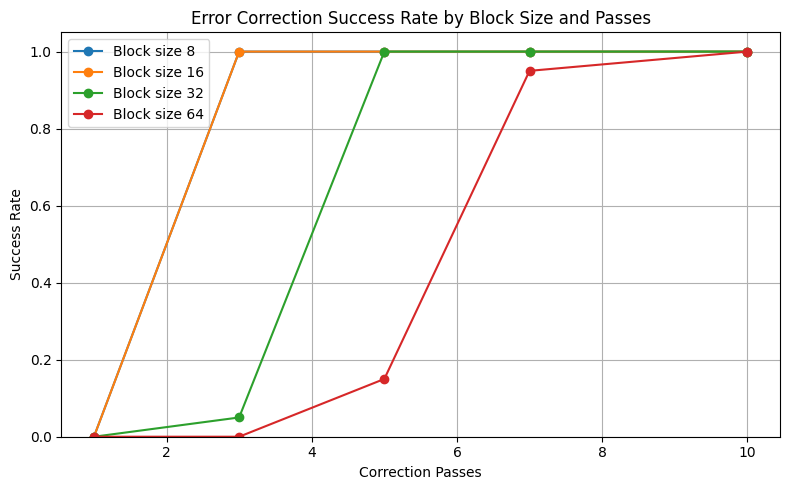

In [4]:
plt.figure(figsize=(8, 5))

for block_size in sorted(df["block_size"].unique()):
    subset = df[df["block_size"] == block_size]

    plt.plot(
        subset["passes"],
        subset["success_rate"],
        marker="o",
        label=f"Block size {block_size}"
    )

plt.xlabel("Correction Passes")
plt.ylabel("Success Rate")
plt.title("Error Correction Success Rate by Block Size and Passes")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("../figures/error_correction_success_rate.png", dpi=300)
plt.show()

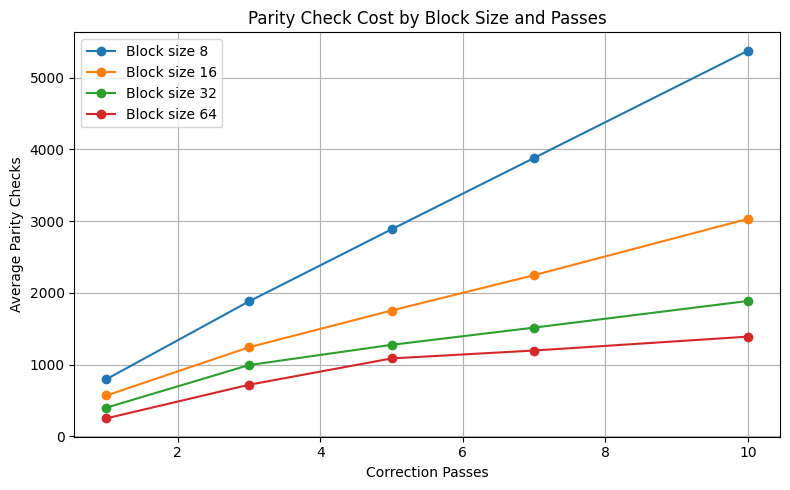

In [5]:
plt.figure(figsize=(8, 5))

for block_size in sorted(df["block_size"].unique()):
    subset = df[df["block_size"] == block_size]

    plt.plot(
        subset["passes"],
        subset["average_parity_checks"],
        marker="o",
        label=f"Block size {block_size}"
    )

plt.xlabel("Correction Passes")
plt.ylabel("Average Parity Checks")
plt.title("Parity Check Cost by Block Size and Passes")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("../figures/error_correction_parity_checks.png", dpi=300)
plt.show()

## Error Correction Parameter Sweep

This notebook studies how parity-based error correction behaves under different block sizes and pass counts.

The experiment varies:

- block size
- number of correction passes

For each setting, the simulation records the success rate, average QBER, raw mismatches, final mismatches, corrections applied, and parity checks.

The goal is to understand the tradeoff between correction reliability and correction cost. More passes usually improve success rate, but they also increase the number of parity checks.